In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import time
import threading
import matplotlib.pyplot as plt

In [2]:
# ==============================
# SEQUENTIAL BUBBLE SORT
# ==============================
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]

In [3]:
# ==============================
# PARALLEL BUBBLE SORT (ODD-EVEN)
# ==============================
def parallel_bubble_sort(arr):
    n = len(arr)

    def odd_phase():
        for i in range(1, n-1, 2):
            if arr[i] > arr[i+1]:
                arr[i], arr[i+1] = arr[i+1], arr[i]

    def even_phase():
        for i in range(0, n-1, 2):
            if arr[i] > arr[i+1]:
                arr[i], arr[i+1] = arr[i+1], arr[i]

    for _ in range(n):
        t1 = threading.Thread(target=odd_phase)
        t2 = threading.Thread(target=even_phase)

        t1.start()
        t2.start()

        t1.join()
        t2.join()

In [4]:
# ==============================
# USER INPUT
# ==============================
n = int(input("Enter number of elements: "))
arr = list(map(int, input("Enter elements: ").split()))

arr_seq = arr.copy()
arr_par = arr.copy()

Enter number of elements: 20
Enter elements: 45 23 78 12 56 89 11 67 34 90 21 43 65 87 32 10 54 76 98 1


In [5]:
# ==============================
# TIME MEASUREMENT
# ==============================
start = time.time()
bubble_sort(arr_seq)
end = time.time()
seq_time = end - start

start = time.time()
parallel_bubble_sort(arr_par)
end = time.time()
par_time = end - start


In [6]:
# ==============================
# OUTPUT
# ==============================
print("\nSequential Sorted:", arr_seq)
print("Parallel Sorted:", arr_par)

print("\nSequential Time:", seq_time)
print("Parallel Time:", par_time)


Sequential Sorted: [1, 10, 11, 12, 21, 23, 32, 34, 43, 45, 54, 56, 65, 67, 76, 78, 87, 89, 90, 98]
Parallel Sorted: [1, 10, 11, 12, 21, 23, 32, 34, 43, 45, 54, 56, 65, 67, 76, 78, 87, 89, 90, 98]

Sequential Time: 0.00015807151794433594
Parallel Time: 0.021096467971801758


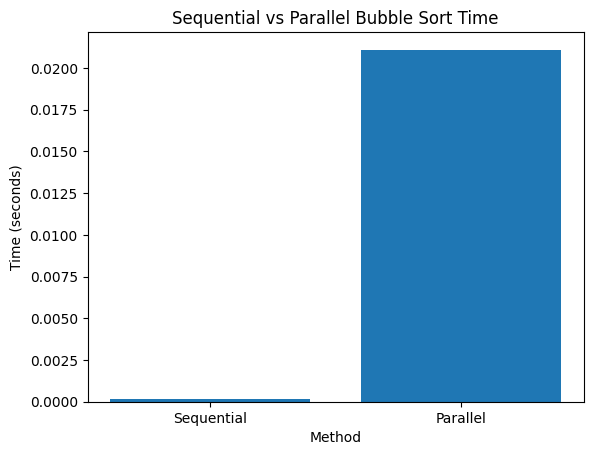

In [7]:
# ==============================
# GRAPH: TIME COMPARISON
# ==============================
plt.figure()

methods = ["Sequential", "Parallel"]
times = [seq_time, par_time]

plt.bar(methods, times)
plt.title("Sequential vs Parallel Bubble Sort Time")
plt.xlabel("Method")
plt.ylabel("Time (seconds)")

plt.show()